CORE LIBRARY

In [35]:
import joblib
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder

CONNECTING GOOGLE DRIVE

In [36]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


DATA SETS FROM DRIVE

In [37]:
folder_path = '/content/drive/MyDrive/car_resell/'

train_data = pd.read_csv(folder_path + 'train.csv')
test_data = pd.read_csv(folder_path + 'test.csv')
test_labels = pd.read_csv(folder_path + 'test_labels.csv')

CLEAN MILEAGE COLUMN

In [38]:
train_data["mileage"] = pd.to_numeric(train_data["mileage"], errors="coerce")
test_data["mileage"] = pd.to_numeric(test_data["mileage"], errors="coerce")

IMPUTE MISSING VALUES WITH MEDIAN

In [39]:
mileage_median = train_data["mileage"].median()
train_data["mileage"] = train_data["mileage"].fillna(mileage_median)
test_data["mileage"] = test_data["mileage"].fillna(mileage_median)

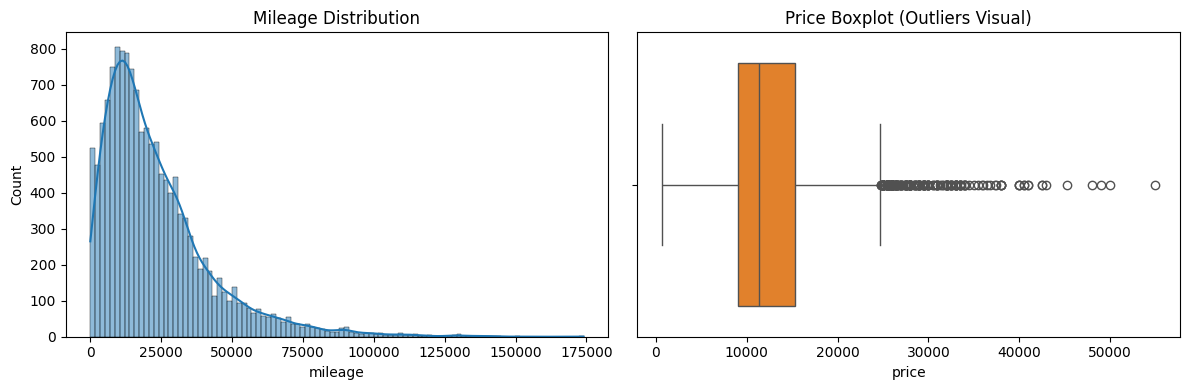

In [40]:
# @title PLACE DATA DISTRIBUTION PLOT {"run":"auto","vertical-output":true,"single-column":true}
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(train_data['mileage'], kde=True, color='#1f77b4')
plt.title('Mileage Distribution')

plt.subplot(1, 2, 2)
sns.boxplot(x=train_data['price'], color='#ff7f0e')
plt.title('Price Boxplot (Outliers Visual)')

plt.tight_layout()
plt.show()

SEPRATE FEATURES AND LABELS

In [41]:
X_train = train_data.drop("price", axis=1)
y_train = train_data["price"]
X_test = test_data.copy()
y_test = test_labels["price"]

ENCODE TEXT COLUMNS

In [42]:
text_columns = ["model", "transmission", "fuelType"]
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

encoded_train_array = encoder.fit_transform(X_train[text_columns])
encoded_test_array = encoder.transform(X_test[text_columns])
encoded_col_names = encoder.get_feature_names_out(text_columns)

encoded_train_df = pd.DataFrame(
    encoded_train_array, columns=encoded_col_names, index=X_train.index
)
encoded_test_df = pd.DataFrame(
    encoded_test_array, columns=encoded_col_names, index=X_test.index
)

COMBINE NUMERICAL AND ENCODED FEATURES

In [ ]:
number_columns = ["year", "mileage", "tax", "mpg", "engineSize"]
X_train_final = pd.concat([X_train[number_columns], encoded_train_df], axis=1)
X_test_final = pd.concat([X_test[number_columns], encoded_test_df], axis=1)

/tmp/ipykernel_2600/408327064.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='transmission', y='price', data=train_data, palette='Blues_d')


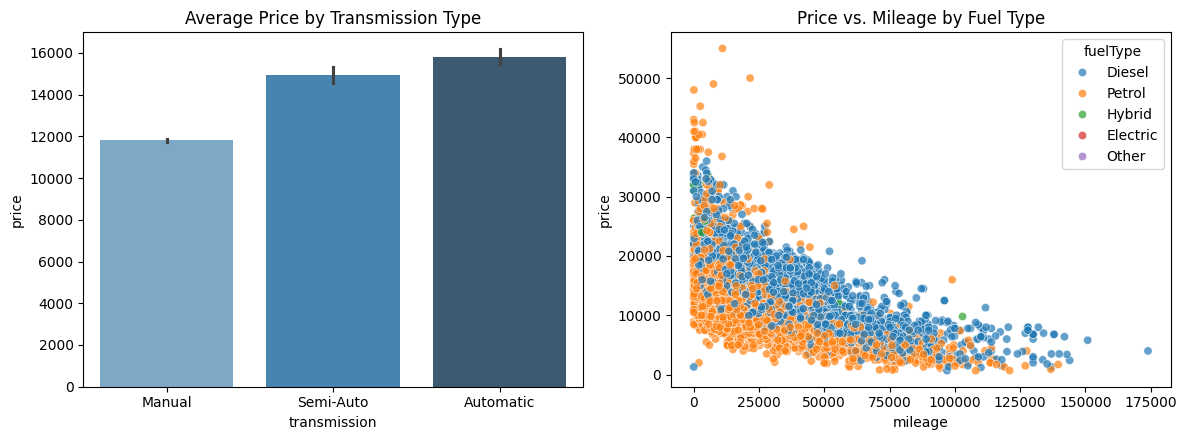

In [ ]:
# @title PLACE FEATURE RELATIONSHIP PLOT {"run":"auto","vertical-output":true,"single-column":true}
plt.figure(figsize=(12, 4.5))

plt.subplot(1, 2, 1)
sns.barplot(x='transmission', y='price', data=train_data, palette='Blues_d')
plt.title('Average Price by Transmission Type')

plt.subplot(1, 2, 2)
sns.scatterplot(x='mileage', y='price', hue='fuelType', data=train_data, alpha=0.7)
plt.title('Price vs. Mileage by Fuel Type')

plt.tight_layout()
plt.show()

TRAIN RANDOM FOREST MODEL

In [43]:
model = RandomForestRegressor(n_estimators=15, max_depth=5, random_state=42)
model.fit(X_train_final, y_train)

RandomForestRegressor(max_depth=5, n_estimators=15, random_state=42)

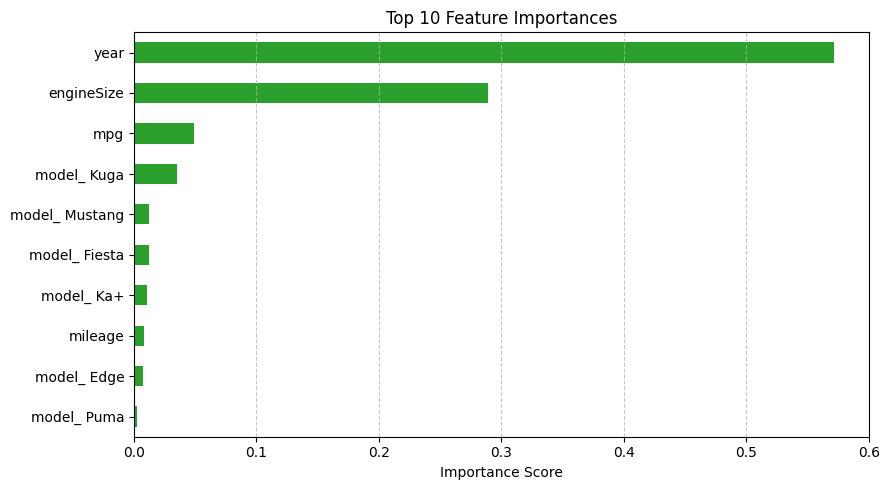

In [ ]:
# @title PLACE FEATURE IMPORTANCE BAR CHART {"run":"auto","vertical-output":true,"single-column":true}
import pandas as pd

importances = pd.Series(model.feature_importances_, index=X_train_final.columns)
top_importances = importances.nlargest(10).sort_values(ascending=True)

plt.figure(figsize=(9, 5))
top_importances.plot(kind='barh', color='#2ca02c')
plt.title('Top 10 Feature Importances')
plt.xlabel('Importance Score')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

EVALUATE MODEL

In [ ]:
predictions = model.predict(X_test_final)
mae_score = mean_absolute_error(y_test, predictions)
rmse_score = np.sqrt(mean_squared_error(y_test, predictions))
r2_result = r2_score(y_test, predictions)

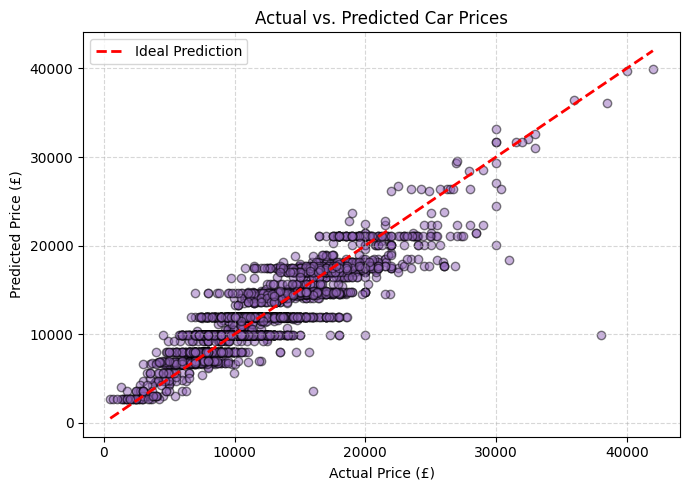

In [ ]:
# @title PLACE ACTUAL V/S PRIDECTED PERFORMANCE PLOT {"run":"auto","vertical-output":true,"single-column":true}
plt.figure(figsize=(7, 5))
plt.scatter(y_test, predictions, alpha=0.5, color='#9467bd', edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal Prediction')
plt.title('Actual vs. Predicted Car Prices')
plt.xlabel('Actual Price (£)')
plt.ylabel('Predicted Price (£)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

PRINT SUMMARY

In [44]:
print("=== Model Performance Summary ===")
print("R² Score:", round(r2_result, 4))
print("Normalized Score (0 to 10):", round(r2_result * 10, 2), "/ 10.0")
print("Mean Absolute Error (MAE): £", round(mae_score, 2))
print("Root Mean Squared Error (RMSE): £", round(rmse_score, 2))

=== Model Performance Summary ===
R² Score: 0.8173
Normalized Score (0 to 10): 8.17 / 10.0
Mean Absolute Error (MAE): £ 1494.53
Root Mean Squared Error (RMSE): £ 2023.54


In [45]:
metrics = {
    "r2": r2_result,
    "mae": mae_score,
    "rmse": rmse_score,
    "models": sorted(train_data["model"].dropna().unique().tolist()),
    "transmissions": sorted(
        train_data["transmission"].dropna().unique().tolist()
    ),
    "fuels": sorted(train_data["fuelType"].dropna().unique().tolist()),
}

joblib.dump(model, "car_model.pkl")
joblib.dump(encoder, "encoder.pkl")
joblib.dump(metrics, "metrics.pkl")
print("\n✅ Trained model and artifacts saved to disk successfully!")


✅ Trained model and artifacts saved to disk successfully!


-------------------FRONT END------------------------

In [47]:
import os
import subprocess
import time
from pyngrok import conf, ngrok

# 1. Write app.py to disk
app_code = """import joblib
import pandas as pd
import streamlit as st

st.set_page_config(page_title="Car Price Predictor", page_icon="🚗", layout="wide")
st.title("🚗 Used Car Price Prediction & Analytics")
st.write("Estimate car prices in real-time using your pre-trained Machine Learning model.")

@st.cache_resource
def load_assets():
    model = joblib.load("car_model.pkl")
    encoder = joblib.load("encoder.pkl")
    metrics = joblib.load("metrics.pkl")
    return model, encoder, metrics

try:
    model, encoder, metrics = load_assets()

    st.sidebar.header("📊 Model Metrics")
    st.sidebar.metric("R² Score", f"{metrics['r2']:.4f}")
    st.sidebar.metric("Score Rating", f"{metrics['r2'] * 10:.2f} / 10")
    st.sidebar.metric("MAE", f"£{metrics['mae']:,.2f}")
    st.sidebar.metric("RMSE", f"£{metrics['rmse']:,.2f}")

    st.subheader("Vehicle Input Details")
    col1, col2 = st.columns(2)

    with col1:
        car_model = st.selectbox("Car Model", metrics["models"])
        year = st.number_input("Year", min_value=1990, max_value=2026, value=2018)
        mileage = st.number_input("Mileage", min_value=0, value=30000)
        tax = st.number_input("Road Tax (£)", min_value=0, value=150)

    with col2:
        transmission = st.selectbox("Transmission", metrics["transmissions"])
        fuel_type = st.selectbox("Fuel Type", metrics["fuels"])
        mpg = st.number_input("Miles Per Gallon (MPG)", min_value=0.0, value=50.0)
        engine_size = st.number_input("Engine Size (L)", min_value=0.0, max_value=10.0, value=2.0)

    if st.button("Predict Valuation", use_container_width=True):
        text_cols = ["model", "transmission", "fuelType"]
        input_text_df = pd.DataFrame([{"model": car_model, "transmission": transmission, "fuelType": fuel_type}])

        encoded_array = encoder.transform(input_text_df[text_cols])
        encoded_df = pd.DataFrame(encoded_array, columns=encoder.get_feature_names_out(text_cols))

        input_num_df = pd.DataFrame([{"year": year, "mileage": mileage, "tax": tax, "mpg": mpg, "engineSize": engine_size}])
        final_input = pd.concat([input_num_df, encoded_df], axis=1)

        prediction = model.predict(final_input)[0]

        st.markdown("---")
        st.success(f"### Estimated Price: £{prediction:,.2f}")

except Exception as e:
    st.error(f"Error loading model files (car_model.pkl, encoder.pkl, metrics.pkl): {e}")
"""

with open("app.py", "w", encoding="utf-8") as f:
    f.write(app_code)

print("✅ Created app.py successfully.")

# 2. Configure ngrok credentials
AUTHTOKEN = "3Ian9TMHjCPJ2VuymrP9cLXU0lH_5WLk8vfteL4QpX6VevCA5"
DOMAIN = "amnesty-promotion-voucher.ngrok-free.dev"

conf.get_default().auth_token = AUTHTOKEN
ngrok.kill()

# 3. Launch Streamlit server in background
subprocess.Popen(["streamlit", "run", "app.py", "--server.port", "8501"])
time.sleep(3)

# 4. Connect tunnel to public URL
try:
    public_url = ngrok.connect(8501, domain=DOMAIN)
    print(f"\n🚀 Live Web Application: {public_url}\n")
except Exception as e:
    public_url = ngrok.connect(8501)
    print(f"\n🚀 Live Web Application: {public_url}\n")

✅ Created app.py successfully.

🚀 Live Web Application: NgrokTunnel: "https://amnesty-promotion-voucher.ngrok-free.dev" -> "http://localhost:8501"

